# Mobile App Regression Analysis — Student Academic Performance

**Use Case:** Predicting a student's academic score in ANY subject based on their study habits, attendance, extracurricular involvement, demographic info, and other subject scores.

**Mission:** Schools and educators want to identify students who may struggle in a subject BEFORE they fail. If we can predict a student's score from things we already know, then teachers can intervene early and provide targeted support.

**Dataset:** Student Academic Performance dataset — 2,000 students with 17 columns.
- **Source:** Kaggle / Academic performance datasets
- **Volume:** 2,000 rows (students)
- **Variety:** 17 columns — mix of numeric (scores, study hours, absences), boolean (part-time job, extracurricular), and categorical (gender, career aspiration)

### Assignment Requirements Checklist:
1. ✅ Use case is not generic — predicting student academic performance for early intervention
2. ✅ Dataset is RICH in volume (2000 rows) and variety (17 columns, mixed types)
3. ✅ Brief description and source of data included above
4. ✅ Meaningful visualizations that affect training outcome (heatmap, histograms, scatter plots)
5. ✅ Linear Regression, Decision Tree, and Random Forest models created
6. ✅ Best model (least loss) saved
7. ✅ Prediction on one data point from test set
8. ✅ Loss curves for train and test data
9. ✅ Scatter plot of before/after with linear regression line

In [9]:
#Import all the necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

print("ALL LIBRARIES IMPORTED SUCCESSFULLY!")

ALL LIBRARIES IMPORTED SUCCESSFULLY!


In [10]:
#Base global styles for visualisation(It gats look nice 😂).
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6) #rc is the runtime configuration of matplotlib
plt.rcParams['font.size'] = 12
print("ALL GLOBAL STYLES SET SUCCESSFULLY!")

ALL GLOBAL STYLES SET SUCCESSFULLY!


In [11]:
#Based on our dataset, we have to decide which subject we want to predict.
TARGET_SUBJECT = 'math_score'

ALL_SUBJECTS = [
    'math_score', 'history_score', 'physics_score',
    'chemistry_score', 'biology_score', 'english_score', 'geography_score'
]

#Validate the target subject
assert TARGET_SUBJECT in ALL_SUBJECTS, f"ERROR: '{TARGET_SUBJECT}' is not valid. Choose from: {ALL_SUBJECTS}"

#The OTHER subjects (not the target) will be used as features
OTHER_SUBJECTS = [s for s in ALL_SUBJECTS if s != TARGET_SUBJECT]

#Clean up name to remove 'score'.
TARGET_DISPLAY = TARGET_SUBJECT.replace('_score', '').title()

print(f"  TARGET SUBJECT: {TARGET_DISPLAY} ({TARGET_SUBJECT})")
print(f"  We will PREDICT: {TARGET_DISPLAY} scores")
print(f"  Using as features: {', '.join([s.replace('_score','').title() for s in OTHER_SUBJECTS])}")
print(f"  Plus: study hours, absences, gender, career aspiration, etc.")

  TARGET SUBJECT: Math (math_score)
  We will PREDICT: Math scores
  Using as features: History, Physics, Chemistry, Biology, English, Geography
  Plus: study hours, absences, gender, career aspiration, etc.


In [12]:
#Load data here.
df = pd.read_csv('/content/sample_data/student-scores 2.csv')
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [13]:
#Columns and their data Types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

## Exploratory Data Analysis (EDA) — Understand the Data
Before we build any model, we MUST understand our data. Think of it like a doctor examining a patient before surgery. We need to know:
- Are there missing values? (empty cells)
- What do the numbers look like? (min, max, average)
- Are there any weird patterns or outliers?

In [14]:
#EXPLORATORY DATA ANALYSIS (EDA) — UNDERSTAND THE DATA
print("Missing values per column:")
missing = df.isnull().sum()
print(missing)
print(f"\nThe interpretation is: {'No missing values! Our data is clean.' if missing.sum() == 0 else 'We have missing values to handle!'}")

#Statistical Summary of Numeric Columns
print(df.describe().round(2))

target_stats = df[TARGET_SUBJECT].describe()
print(f"""
INTERPRETATION (focused on our target: {TARGET_DISPLAY}):
  - {TARGET_DISPLAY} score ranges from {target_stats['min']:.0f} to {target_stats['max']:.0f}
  - Average {TARGET_DISPLAY} score: {target_stats['mean']:.1f}
  - Standard deviation: {target_stats['std']:.1f} (how spread out the scores are)
  - 25th percentile: {target_stats['25%']:.0f} (25% of students score below this)
  - 50th percentile (median): {target_stats['50%']:.0f} (the "middle" student)
  - 75th percentile: {target_stats['75%']:.0f} (75% of students score below this)
  - absence_days: ranges from 0 to 10, average ~3.7. Most students attend regularly.
  - weekly_self_study_hours: ranges from 0 to 49, average ~18. Wide range!
""")

Missing values per column:
id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

The interpretation is: No missing values! Our data is clean.
            id  absence_days  weekly_self_study_hours  math_score  \
count  2000.00       2000.00                  2000.00     2000.00   
mean   1000.50          3.67                    17.76       83.45   
std     577.49          2.63                    12.13       13.22   
min       1.00          0.00                     0.00       40.00   
25%     5

In [15]:
#Check categorical columns
print(f"\nGender distribution:\n{df['gender'].value_counts()}")
print(f"\nPart-time job distribution:\n{df['part_time_job'].value_counts()}")
print(f"\nExtracurricular activities distribution:\n{df['extracurricular_activities'].value_counts()}")
print(f"\nCareer aspiration distribution:\n{df['career_aspiration'].value_counts()}")


Gender distribution:
gender
female    1002
male       998
Name: count, dtype: int64

Part-time job distribution:
part_time_job
False    1684
True      316
Name: count, dtype: int64

Extracurricular activities distribution:
extracurricular_activities
False    1592
True      408
Name: count, dtype: int64

Career aspiration distribution:
career_aspiration
Software Engineer        315
Business Owner           309
Unknown                  223
Banker                   169
Lawyer                   138
Accountant               126
Doctor                   119
Real Estate Developer     83
Stock Investor            73
Construction Engineer     68
Artist                    67
Game Developer            63
Government Officer        61
Teacher                   59
Designer                  56
Scientist                 39
Writer                    32
Name: count, dtype: int64


## Data Visualizations
Numbers in a table are hard to interpret. Charts make patterns OBVIOUS. A picture is worth a thousand numbers!

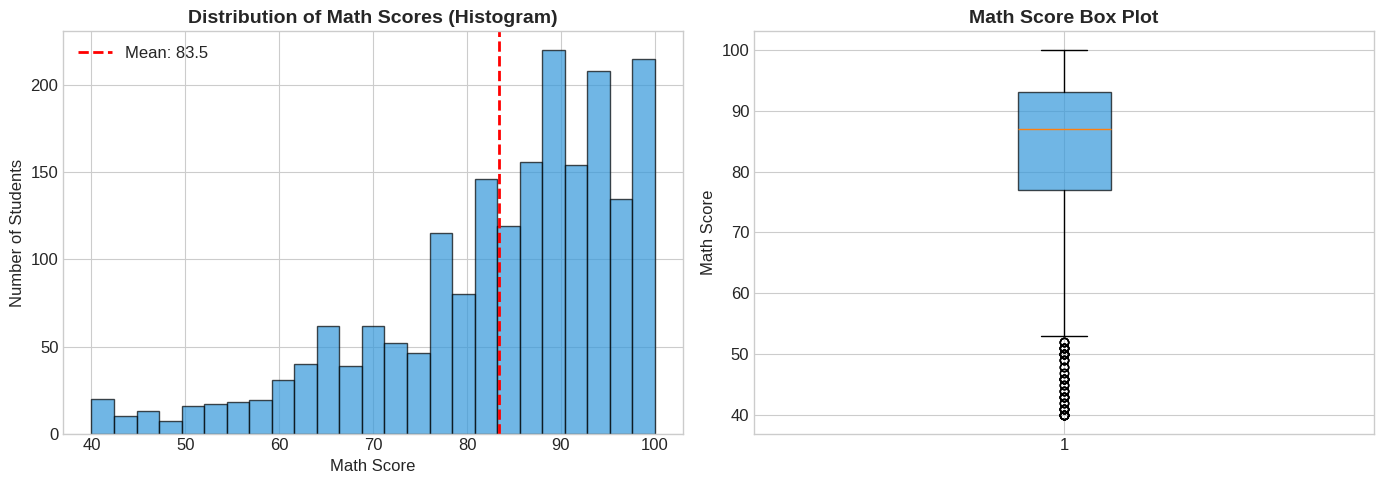

INTERPRETATION: Math scores follow a roughly normal distribution centered
around 83. This is GOOD for regression!


In [16]:
#Plot data distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[TARGET_SUBJECT], bins=25, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Distribution of {TARGET_DISPLAY} Scores (Histogram)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'{TARGET_DISPLAY} Score')
axes[0].set_ylabel('Number of Students')
axes[0].axvline(df[TARGET_SUBJECT].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df[TARGET_SUBJECT].mean():.1f}')
axes[0].legend()

axes[1].boxplot(df[TARGET_SUBJECT], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title(f'{TARGET_DISPLAY} Score Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel(f'{TARGET_DISPLAY} Score')

plt.tight_layout()
plt.show()

print(f"INTERPRETATION: {TARGET_DISPLAY} scores follow a roughly normal distribution centered")
print(f"around {df[TARGET_SUBJECT].mean():.0f}. This is GOOD for regression!")

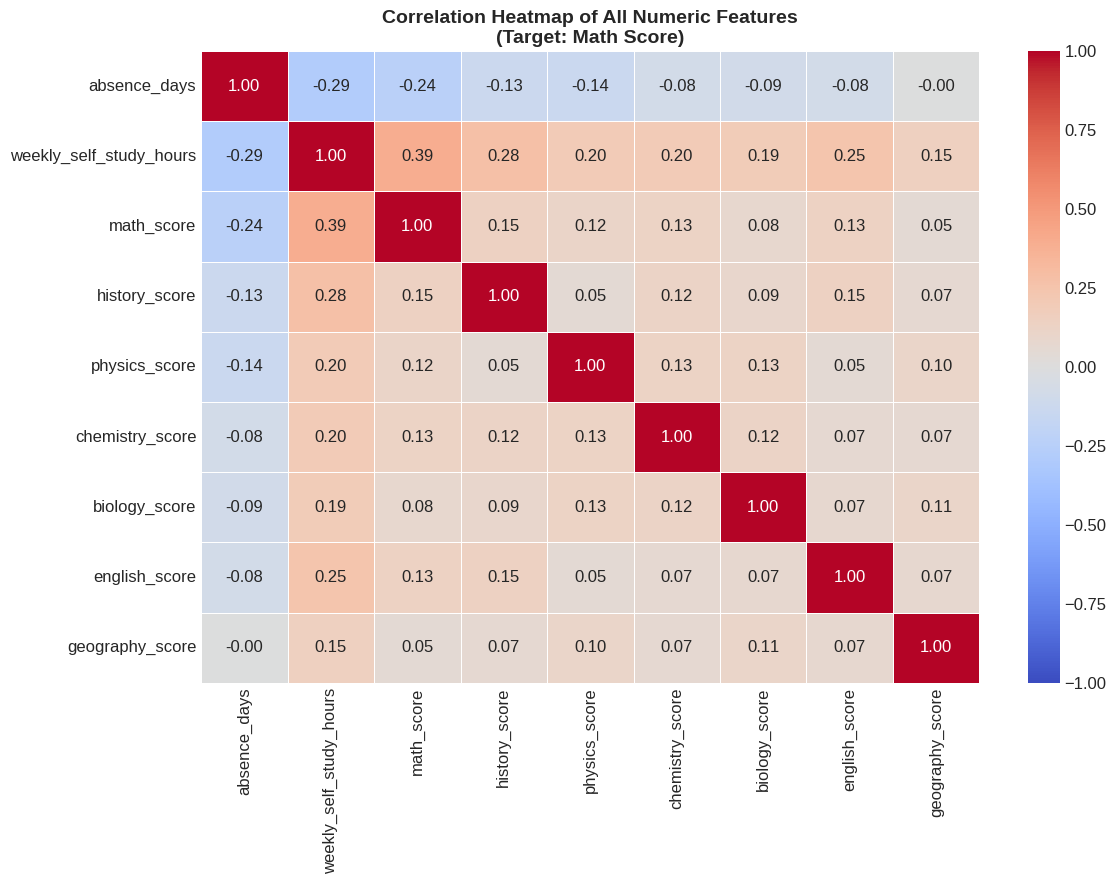

In [17]:
#Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('id')

fig, ax = plt.subplots(figsize=(12, 9))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title(f'Correlation Heatmap of All Numeric Features\n(Target: {TARGET_DISPLAY} Score)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
#Top correlations with target
target_corr = correlation_matrix[TARGET_SUBJECT].drop(TARGET_SUBJECT).sort_values(ascending=False)
for feature, corr_val in target_corr.items():
    bar = chr(9608) * int(abs(corr_val) * 30)
    direction = "positive" if corr_val > 0 else "negative"
    print(f"    {feature:30s} {corr_val:+.3f}  {bar}  ({direction})")

    weekly_self_study_hours        +0.394  ███████████  (positive)
    history_score                  +0.147  ████  (positive)
    english_score                  +0.135  ████  (positive)
    chemistry_score                +0.127  ███  (positive)
    physics_score                  +0.116  ███  (positive)
    biology_score                  +0.081  ██  (positive)
    geography_score                +0.050  █  (positive)
    absence_days                   -0.237  ███████  (negative)


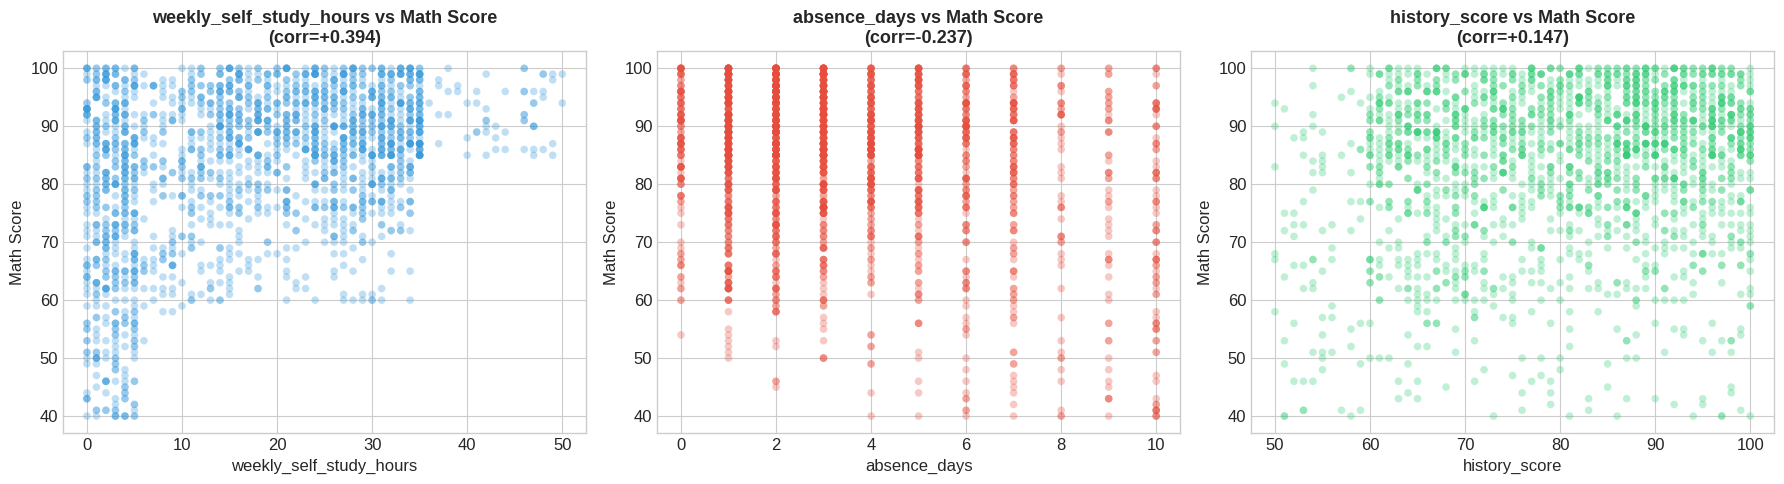

INTERPRETATION: These show the 3 features most correlated with Math score.
  - weekly_self_study_hours: positive relationship (corr=+0.394)
  - absence_days: negative relationship (corr=-0.237)
  - history_score: positive relationship (corr=+0.147)


In [19]:
#Top 3 Correlated Features vs Target
top_features = target_corr.abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (ax, feature, color) in enumerate(zip(axes, top_features, colors)):
    ax.scatter(df[feature], df[TARGET_SUBJECT],
               alpha=0.3, color=color, edgecolors='none', s=30)
    ax.set_title(f'{feature} vs {TARGET_DISPLAY} Score\n(corr={target_corr[feature]:+.3f})',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'{TARGET_DISPLAY} Score')

plt.tight_layout()
plt.show()

print(f"INTERPRETATION: These show the 3 features most correlated with {TARGET_DISPLAY} score.")
for feat in top_features:
    direction = "positive" if target_corr[feat] > 0 else "negative"
    print(f"  - {feat}: {direction} relationship (corr={target_corr[feat]:+.3f})")

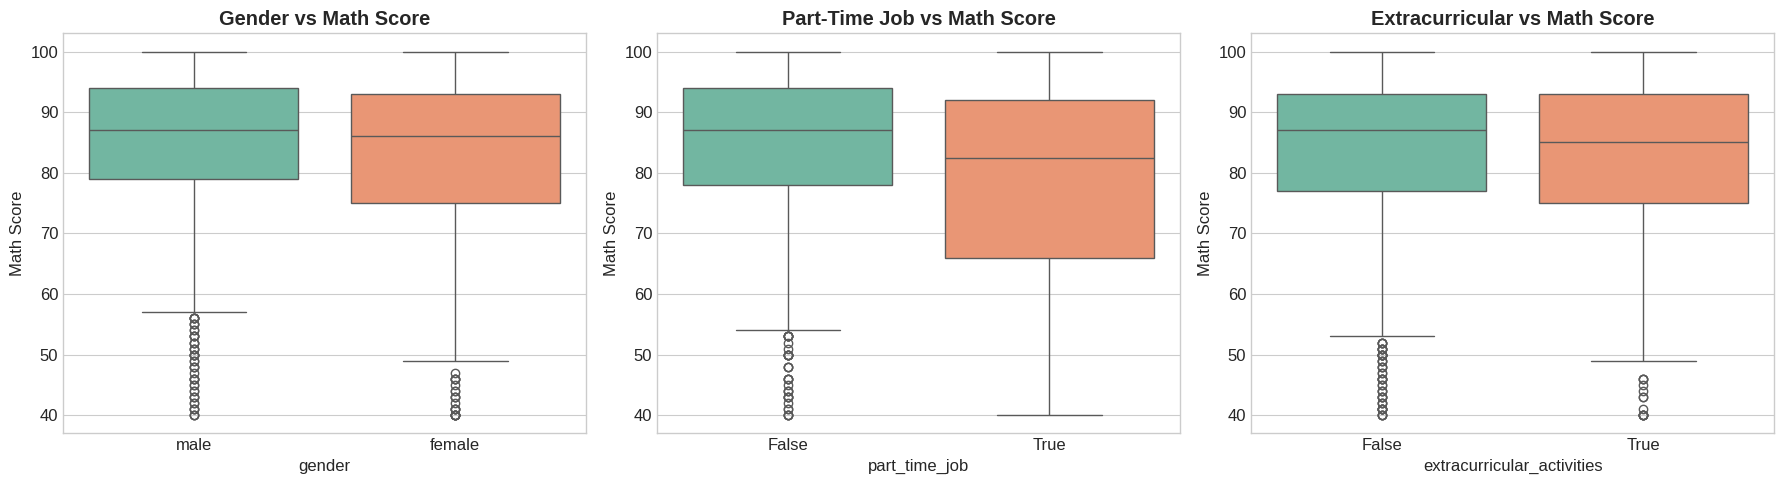

In [20]:
#Categorical Features vs Target
features = ['gender', 'part_time_job', 'extracurricular_activities']
titles = ['Gender', 'Part-Time Job', 'Extracurricular']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(features):
    sns.boxplot(data=df, x=col, y=TARGET_SUBJECT, ax=axes[i], palette='Set2', hue=col, legend=False)
    axes[i].set_title(f'{titles[i]} vs {TARGET_DISPLAY} Score', fontweight='bold')
    axes[i].set_ylabel(f'{TARGET_DISPLAY} Score')

plt.tight_layout()
plt.show()

## Feature Engineering
This is where we decide:
1. Which columns to **DROP** (they don't help prediction)
2. Which columns to **KEEP** (they contain useful signal)
3. Which columns need to be **CONVERTED** (text to numbers)

Think of it like packing for a trip - you take what is useful and leave behind what is not.

In [21]:
#Drop some data we don't need.
columns_to_drop = ['id', 'first_name', 'last_name', 'email']
df_clean = df.drop(columns=columns_to_drop)

print(f"Columns DROPPED: {columns_to_drop}")
print("REASON: These are identifiers (row number, names, email) that carry ZERO predictive power.")

#Check if we need to convert some datatypes to number
print("\nColumns that need conversion to numeric:")
categorical_cols = df_clean.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in categorical_cols:
    unique_vals = df_clean[col].unique()
    print(f"  '{col}': {len(unique_vals)} unique values -> {list(unique_vals[:10])}\n")

df_clean.head()

Columns DROPPED: ['id', 'first_name', 'last_name', 'email']
REASON: These are identifiers (row number, names, email) that carry ZERO predictive power.

Columns that need conversion to numeric:
  'gender': 2 unique values -> ['male', 'female']

  'part_time_job': 2 unique values -> [np.False_, np.True_]

  'extracurricular_activities': 2 unique values -> [np.False_, np.True_]

  'career_aspiration': 17 unique values -> ['Lawyer', 'Doctor', 'Government Officer', 'Artist', 'Unknown', 'Software Engineer', 'Teacher', 'Business Owner', 'Scientist', 'Banker']



,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


### Feature Importance Reasoning

**Features expected to have HIGH importance (strong predictors):**
- weekly_self_study_hours - direct impact on academic performance
- absence_days - missing class means missing lessons (negative effect)
- Other subject scores - Students who do well in one subject tend to do well in others

**Features expected to have MODERATE importance:**
- career_aspiration - motivation/direction matters
- part_time_job - indirect effect via study time

**Features expected to have LOW importance:**
- gender - should not strongly predict academic ability
- extracurricular_activities - indirect effect, could go either way

In [22]:
#CONVERTING CATEGORICAL DATA TO NUMERIC
# Binary columns: Label Encoding (2 values to 0 and 1)
le_gender = LabelEncoder()
df_clean['gender'] = le_gender.fit_transform(df_clean['gender'])
print(f"  gender: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

df_clean['part_time_job'] = df_clean['part_time_job'].astype(int)
print(f"  part_time_job: False->0, True->1")

df_clean['extracurricular_activities'] = df_clean['extracurricular_activities'].astype(int)
print(f"  extracurricular_activities: False->0, True->1")

# Multi-category column: One-Hot Encoding (17 careers to 16 binary columns)
# We use drop_first=True to avoid the "dummy variable trap"
print(f"\nOne-Hot Encoding 'career_aspiration' (17 categories)...")
df_clean = pd.get_dummies(df_clean, columns=['career_aspiration'], drop_first=True, dtype=int)
print(f"  Created {len([c for c in df_clean.columns if 'career_aspiration' in c])} new binary columns")

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"  -> {df_clean.shape[0]} students, {df_clean.shape[1]} features (all numeric now!)")
print(f"  All columns numeric? {all(df_clean.dtypes != 'object')}")

  gender: {'female': np.int64(0), 'male': np.int64(1)}
  part_time_job: False->0, True->1
  extracurricular_activities: False->0, True->1

One-Hot Encoding 'career_aspiration' (17 categories)...
  Created 16 new binary columns

Final dataset shape: (2000, 28)
  -> 2000 students, 28 features (all numeric now!)
  All columns numeric? True


## Separate Features (X) and Target (y), then Standardise
- **X** = features (everything EXCEPT our target subject) - the INPUTS
- **y** = target (our chosen subject score) - what we are PREDICTING

**Standardisation** puts all features on the same scale (mean=0, std=1). Without it, features with bigger numbers would dominate unfairly.

**Important:** We fit the scaler on TRAINING data only to avoid "data leakage".

In [23]:
#SEPARATE FEATURES (X) AND TARGET (y)
X = df_clean.drop(columns=[TARGET_SUBJECT])
y = df_clean[TARGET_SUBJECT]

print(f"\nTarget variable: {TARGET_SUBJECT} ({TARGET_DISPLAY} scores)")
print(f"Features (X) shape: {X.shape}  -> {X.shape[0]} students, {X.shape[1]} input features")
print(f"Target (y) shape: {y.shape}    -> {y.shape[0]} {TARGET_DISPLAY} scores to predict")

print(f"\nFeatures being used ({X.shape[1]} total):")
for i, col in enumerate(X.columns):
    print(f"  {i+1:2d}. {col}")


Target variable: math_score (Math scores)
Features (X) shape: (2000, 27)  -> 2000 students, 27 input features
Target (y) shape: (2000,)    -> 2000 Math scores to predict

Features being used (27 total):
   1. gender
   2. part_time_job
   3. absence_days
   4. extracurricular_activities
   5. weekly_self_study_hours
   6. history_score
   7. physics_score
   8. chemistry_score
   9. biology_score
  10. english_score
  11. geography_score
  12. career_aspiration_Artist
  13. career_aspiration_Banker
  14. career_aspiration_Business Owner
  15. career_aspiration_Construction Engineer
  16. career_aspiration_Designer
  17. career_aspiration_Doctor
  18. career_aspiration_Game Developer
  19. career_aspiration_Government Officer
  20. career_aspiration_Lawyer
  21. career_aspiration_Real Estate Developer
  22. career_aspiration_Scientist
  23. career_aspiration_Software Engineer
  24. career_aspiration_Stock Investor
  25. career_aspiration_Teacher
  26. career_aspiration_Unknown
  27. ca

In [24]:
#Split our data using the 80,20 rule.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {X_train.shape[0]} students ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:  {X_test.shape[0]} students ({X_test.shape[0]/len(X)*100:.0f}%)")


Training set: 1600 students (80%)
Testing set:  400 students (20%)


In [25]:
#STANDARDISE THE DATA
# We fit the scaler on TRAINING data only, then transform BOTH.
# This prevents "data leakage" - in real life we wouldn't have test data when building the model.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit AND transform training data
X_test_scaled = scaler.transform(X_test)         # ONLY transform test data (using training stats)

print(f"Before standardization (first sample): {X_train.iloc[0].values[:5]}")
print(f"After standardization (first sample):  {X_train_scaled[0][:5].round(3)}")
print(f"\nStandardization complete! All features now have mean~0 and std~1")

# Convert back to DataFrame for easier handling later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

Before standardization (first sample): [0 0 2 1 6]
After standardization (first sample):  [-0.993 -0.434 -0.638  1.932 -0.983]

Standardization complete! All features now have mean~0 and std~1


## Building the Models
We will build 3 different models:

1. **Linear Regression with Gradient Descent (SGD):** Draws a line through data, uses gradient descent to minimize error step by step.
2. **Decision Tree:** Makes predictions by asking yes/no questions about features. Can overfit.
3. **Random Forest:** Builds MANY decision trees and averages predictions. Reduces overfitting.

In [26]:
results = {}

### LINEAR REGRESSION WITH GRADIENT DESCENT (SGD)
Gradient Descent is like being blindfolded on a hilly landscape - you feel the slope and take steps downhill until you reach the valley (minimum error). SGD looks at small random batches each step for speed.

In [27]:
n_epochs = 200
train_losses_sgd = []
test_losses_sgd = []

sgd_model = SGDRegressor(
    loss='squared_error', learning_rate='adaptive', eta0=0.01,
    max_iter=1, tol=None, warm_start=True, random_state=42,
    penalty='l2', alpha=0.0001
)

for epoch in range(n_epochs):
    sgd_model.partial_fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    train_losses_sgd.append(mean_squared_error(y_train, train_pred))
    test_losses_sgd.append(mean_squared_error(y_test, test_pred))

y_train_pred_sgd = sgd_model.predict(X_train_scaled)
y_test_pred_sgd = sgd_model.predict(X_test_scaled)

results['SGD Linear Regression'] = {
    'Train MSE': mean_squared_error(y_train, y_train_pred_sgd),
    'Test MSE': mean_squared_error(y_test, y_test_pred_sgd),
    'Train R2': r2_score(y_train, y_train_pred_sgd),
    'Test R2': r2_score(y_test, y_test_pred_sgd),
    'Train MAE': mean_absolute_error(y_train, y_train_pred_sgd),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_sgd),
}

print(f"  Training R2:  {results['SGD Linear Regression']['Train R2']:.4f}   |   Testing R2:  {results['SGD Linear Regression']['Test R2']:.4f}")
print(f"  Training MSE: {results['SGD Linear Regression']['Train MSE']:.4f}   |   Testing MSE: {results['SGD Linear Regression']['Test MSE']:.4f}")
print(f"  Testing MAE:  {results['SGD Linear Regression']['Test MAE']:.4f}")

  Training R2:  0.2068   |   Testing R2:  0.1482
  Training MSE: 140.3908   |   Testing MSE: 141.3551
  Testing MAE:  9.4858


### Standard Linear Regression for comparison
This uses the closed-form (Normal Equation) solution instead of gradient descent.

In [28]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

results['Standard Linear Regression'] = {
    'Train MSE': mean_squared_error(y_train, y_train_pred_lr),
    'Test MSE': mean_squared_error(y_test, y_test_pred_lr),
    'Train R2': r2_score(y_train, y_train_pred_lr),
    'Test R2': r2_score(y_test, y_test_pred_lr),
    'Train MAE': mean_absolute_error(y_train, y_train_pred_lr),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_lr),
}
print(f"  Testing R2:  {results['Standard Linear Regression']['Test R2']:.4f}   |   Testing MSE: {results['Standard Linear Regression']['Test MSE']:.4f}")

  Testing R2:  0.2650   |   Testing MSE: 121.9628


### DECISION TREE
A Decision Tree splits data based on feature thresholds - like a flowchart of yes/no questions. max_depth=10 limits tree depth to prevent overfitting.

In [29]:
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_train_pred_dt = dt_model.predict(X_train_scaled)
y_test_pred_dt = dt_model.predict(X_test_scaled)

results['Decision Tree'] = {
    'Train MSE': mean_squared_error(y_train, y_train_pred_dt),
    'Test MSE': mean_squared_error(y_test, y_test_pred_dt),
    'Train R2': r2_score(y_train, y_train_pred_dt),
    'Test R2': r2_score(y_test, y_test_pred_dt),
    'Train MAE': mean_absolute_error(y_train, y_train_pred_dt),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_dt),
}

print(f"  Training R2:  {results['Decision Tree']['Train R2']:.4f}   |   Testing R2:  {results['Decision Tree']['Test R2']:.4f}")
print(f"  Training MSE: {results['Decision Tree']['Train MSE']:.4f}   |   Testing MSE: {results['Decision Tree']['Test MSE']:.4f}")

#Loss curve data
train_losses_dt = []
test_losses_dt = []
depth_range = range(1, 31)
for depth in depth_range:
    dt_temp = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=5, random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    train_losses_dt.append(mean_squared_error(y_train, dt_temp.predict(X_train_scaled)))
    test_losses_dt.append(mean_squared_error(y_test, dt_temp.predict(X_test_scaled)))

  Training R2:  0.5893   |   Testing R2:  0.0159
  Training MSE: 72.6934   |   Testing MSE: 163.3027


### RANDOM FOREST
Random Forest = many Decision Trees working together. Each tree sees a random subset of data/features. Final prediction = average of all trees. This "wisdom of crowds" reduces overfitting.

In [30]:
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

results['Random Forest'] = {
    'Train MSE': mean_squared_error(y_train, y_train_pred_rf),
    'Test MSE': mean_squared_error(y_test, y_test_pred_rf),
    'Train R2': r2_score(y_train, y_train_pred_rf),
    'Test R2': r2_score(y_test, y_test_pred_rf),
    'Train MAE': mean_absolute_error(y_train, y_train_pred_rf),
    'Test MAE': mean_absolute_error(y_test, y_test_pred_rf),
}

print(f"  Training R2:  {results['Random Forest']['Train R2']:.4f}   |   Testing R2:  {results['Random Forest']['Test R2']:.4f}")
print(f"  Training MSE: {results['Random Forest']['Train MSE']:.4f}   |   Testing MSE: {results['Random Forest']['Test MSE']:.4f}")

#Loss curve data
train_losses_rf = []
test_losses_rf = []
estimator_range = range(1, 101, 5)
for n_est in estimator_range:
    rf_temp = RandomForestRegressor(n_estimators=n_est, max_depth=15,
                                     min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train_scaled, y_train)
    train_losses_rf.append(mean_squared_error(y_train, rf_temp.predict(X_train_scaled)))
    test_losses_rf.append(mean_squared_error(y_test, rf_temp.predict(X_test_scaled)))

  Training R2:  0.6687   |   Testing R2:  0.2154
  Training MSE: 58.6318   |   Testing MSE: 130.1938


## Plot Loss Curves
A loss curve shows how model error changes over time/complexity. We plot BOTH training and test loss:
- Both go down together = model is learning well
- Training goes down but test goes UP = **OVERFITTING** (memorized training data)
- Both stay high = **UNDERFITTING** (model too simple)

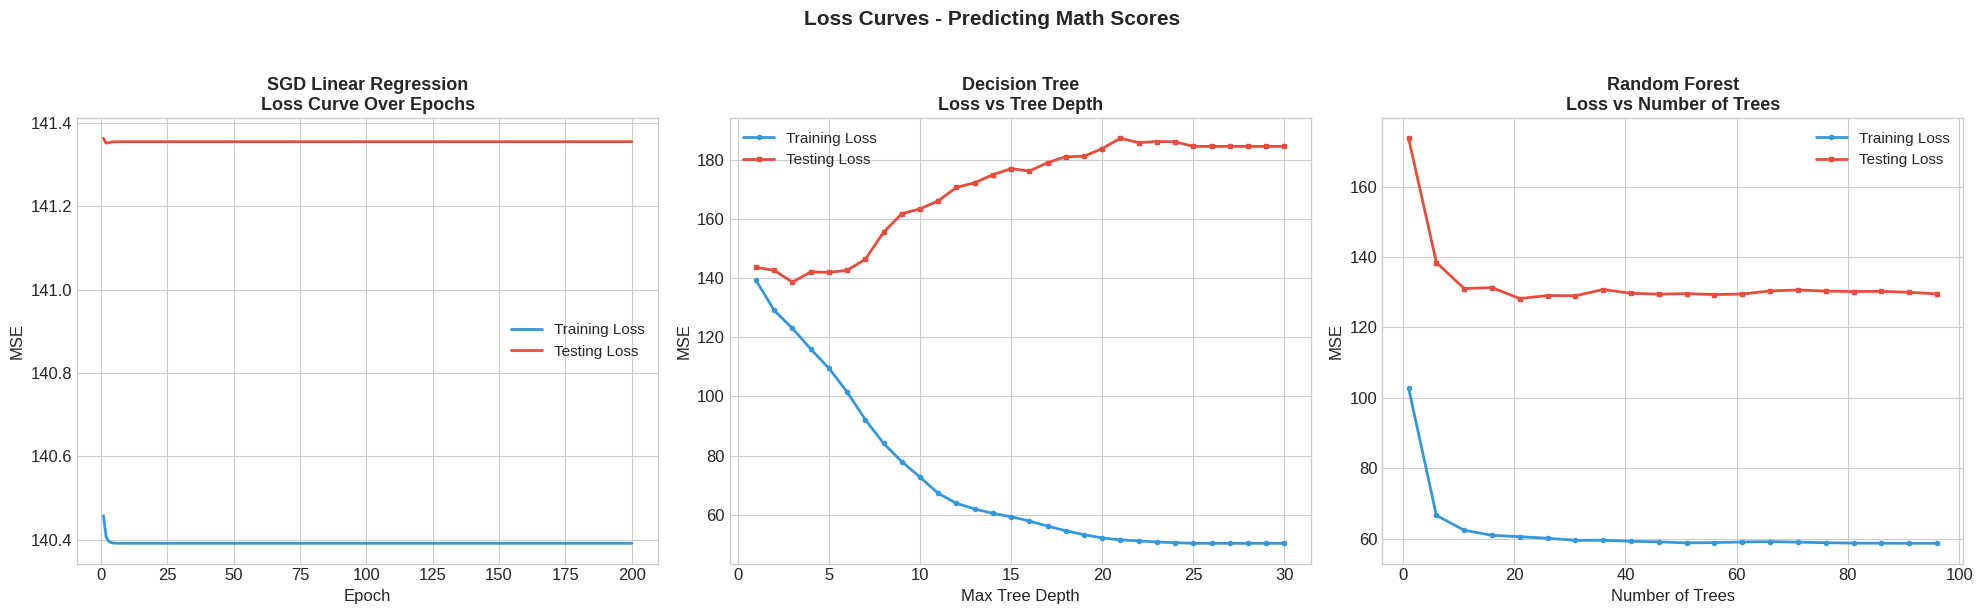

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].plot(range(1, n_epochs+1), train_losses_sgd, label='Training Loss', color='#3498db', linewidth=2)
axes[0].plot(range(1, n_epochs+1), test_losses_sgd, label='Testing Loss', color='#e74c3c', linewidth=2)
axes[0].set_title('SGD Linear Regression\nLoss Curve Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend(fontsize=11)

axes[1].plot(list(depth_range), train_losses_dt, label='Training Loss', color='#3498db', linewidth=2, marker='o', markersize=3)
axes[1].plot(list(depth_range), test_losses_dt, label='Testing Loss', color='#e74c3c', linewidth=2, marker='s', markersize=3)
axes[1].set_title('Decision Tree\nLoss vs Tree Depth', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max Tree Depth')
axes[1].set_ylabel('MSE')
axes[1].legend(fontsize=11)

axes[2].plot(list(estimator_range), train_losses_rf, label='Training Loss', color='#3498db', linewidth=2, marker='o', markersize=3)
axes[2].plot(list(estimator_range), test_losses_rf, label='Testing Loss', color='#e74c3c', linewidth=2, marker='s', markersize=3)
axes[2].set_title('Random Forest\nLoss vs Number of Trees', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Trees')
axes[2].set_ylabel('MSE')
axes[2].legend(fontsize=11)

plt.suptitle(f'Loss Curves - Predicting {TARGET_DISPLAY} Scores', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Scatter Plots - Actual vs Predicted (Before and After)
- **BEFORE** (top row): Baseline - just predicting the mean for everyone. R2 is approximately 0.
- **AFTER** (bottom row): Trained model predictions. Points should cluster around the diagonal "perfect prediction" line.

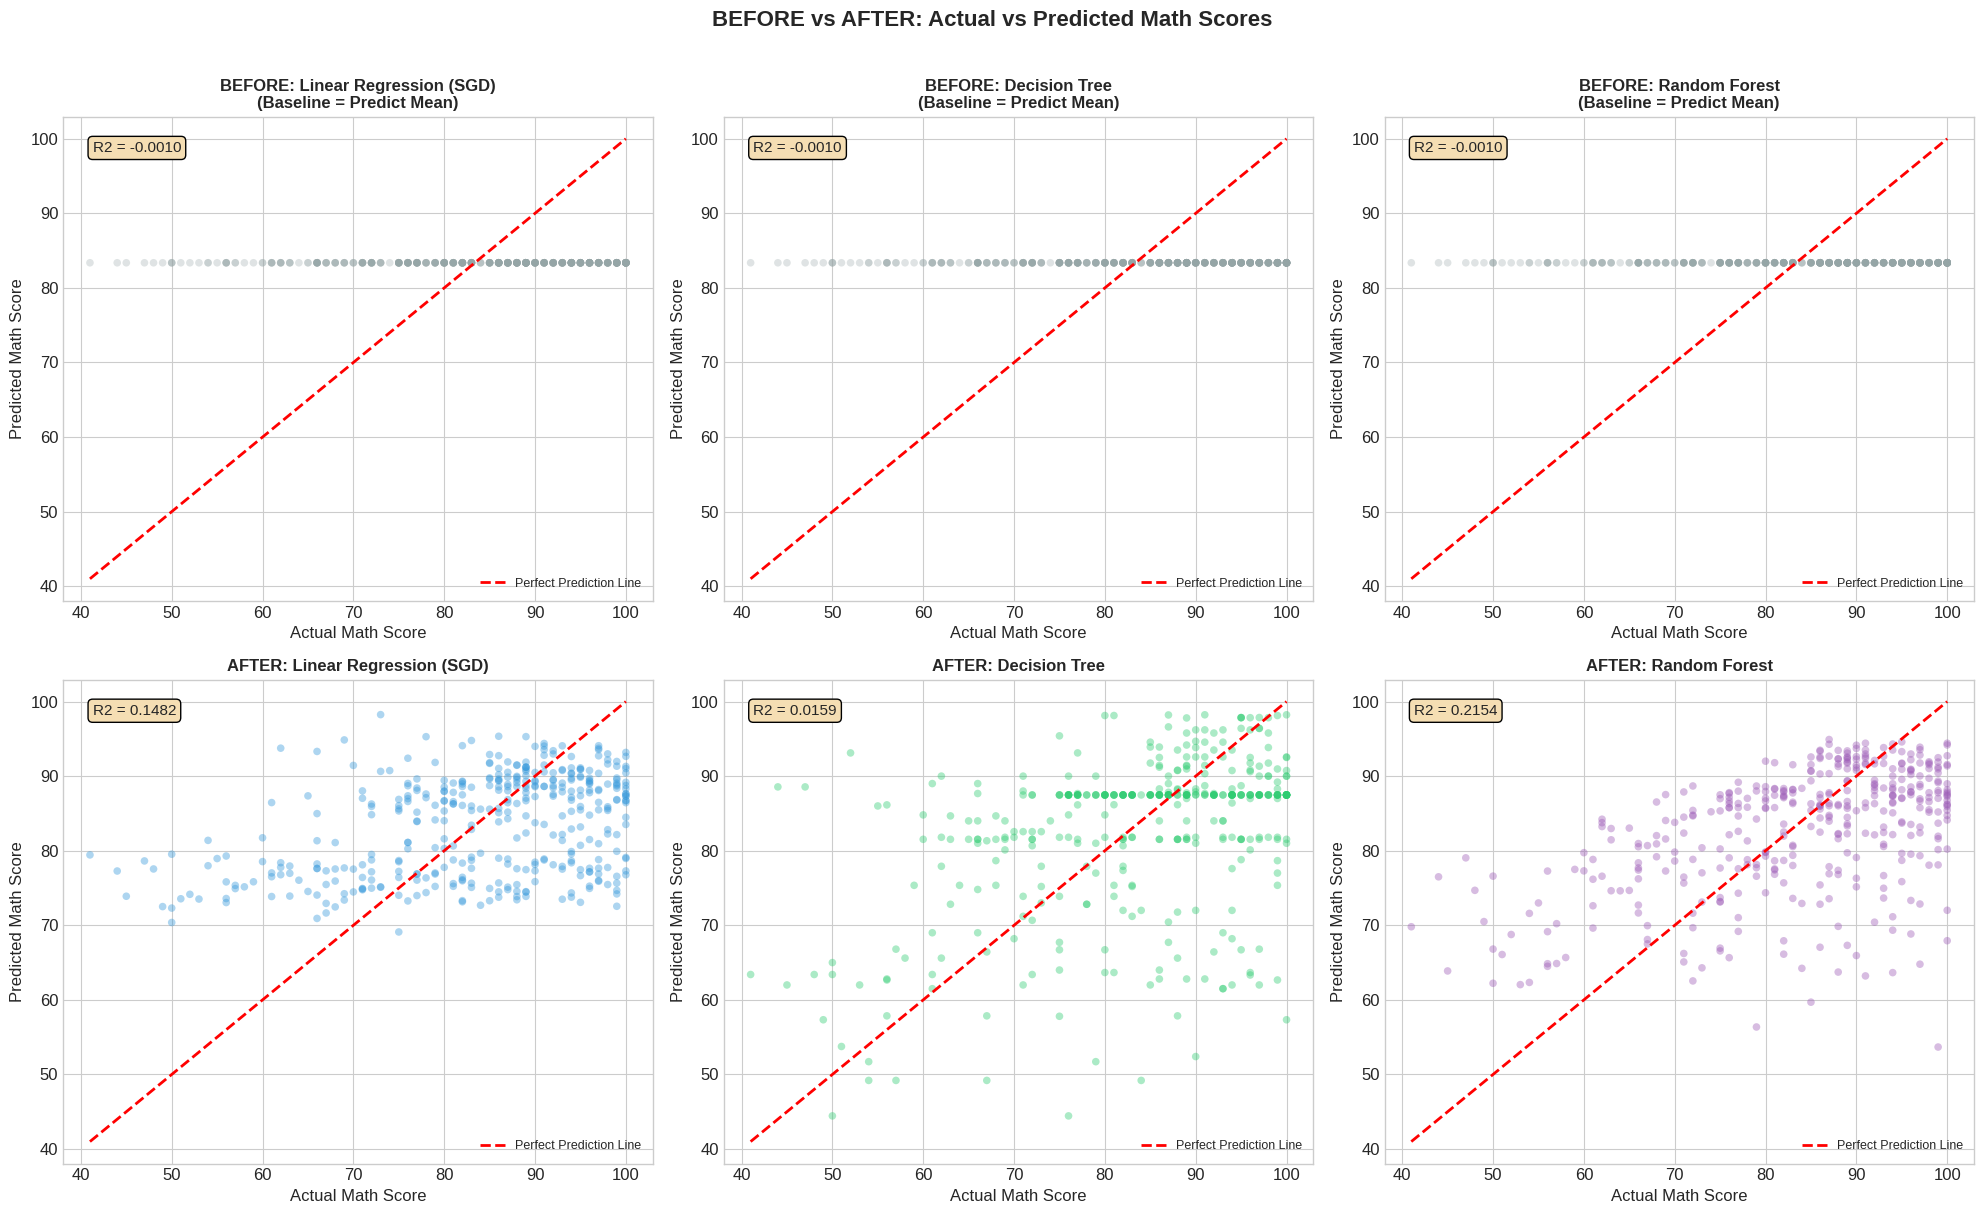

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Row 1: BEFORE (baseline)
mean_pred = np.full_like(y_test.values, y_train.mean(), dtype=float)

for idx, (ax, title) in enumerate(zip(axes[0], ['Linear Regression (SGD)', 'Decision Tree', 'Random Forest'])):
    ax.scatter(y_test, mean_pred, alpha=0.3, color='#95a5a6', edgecolors='none', s=30)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Prediction Line')
    ax.set_title(f'BEFORE: {title}\n(Baseline = Predict Mean)', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Actual {TARGET_DISPLAY} Score')
    ax.set_ylabel(f'Predicted {TARGET_DISPLAY} Score')
    ax.legend(fontsize=9)
    ax.text(0.05, 0.95, f'R2 = {r2_score(y_test, mean_pred):.4f}', transform=ax.transAxes,
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

# Row 2: AFTER (trained models)
predictions = [y_test_pred_sgd, y_test_pred_dt, y_test_pred_rf]
names = ['Linear Regression (SGD)', 'Decision Tree', 'Random Forest']
colors = ['#3498db', '#2ecc71', '#9b59b6']

for idx, (ax, preds, name, color) in enumerate(zip(axes[1], predictions, names, colors)):
    ax.scatter(y_test, preds, alpha=0.4, color=color, edgecolors='none', s=30)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Perfect Prediction Line')
    ax.set_title(f'AFTER: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Actual {TARGET_DISPLAY} Score')
    ax.set_ylabel(f'Predicted {TARGET_DISPLAY} Score')
    ax.legend(fontsize=9)
    ax.text(0.05, 0.95, f'R2 = {r2_score(y_test, preds):.4f}', transform=ax.transAxes,
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle(f'BEFORE vs AFTER: Actual vs Predicted {TARGET_DISPLAY} Scores',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

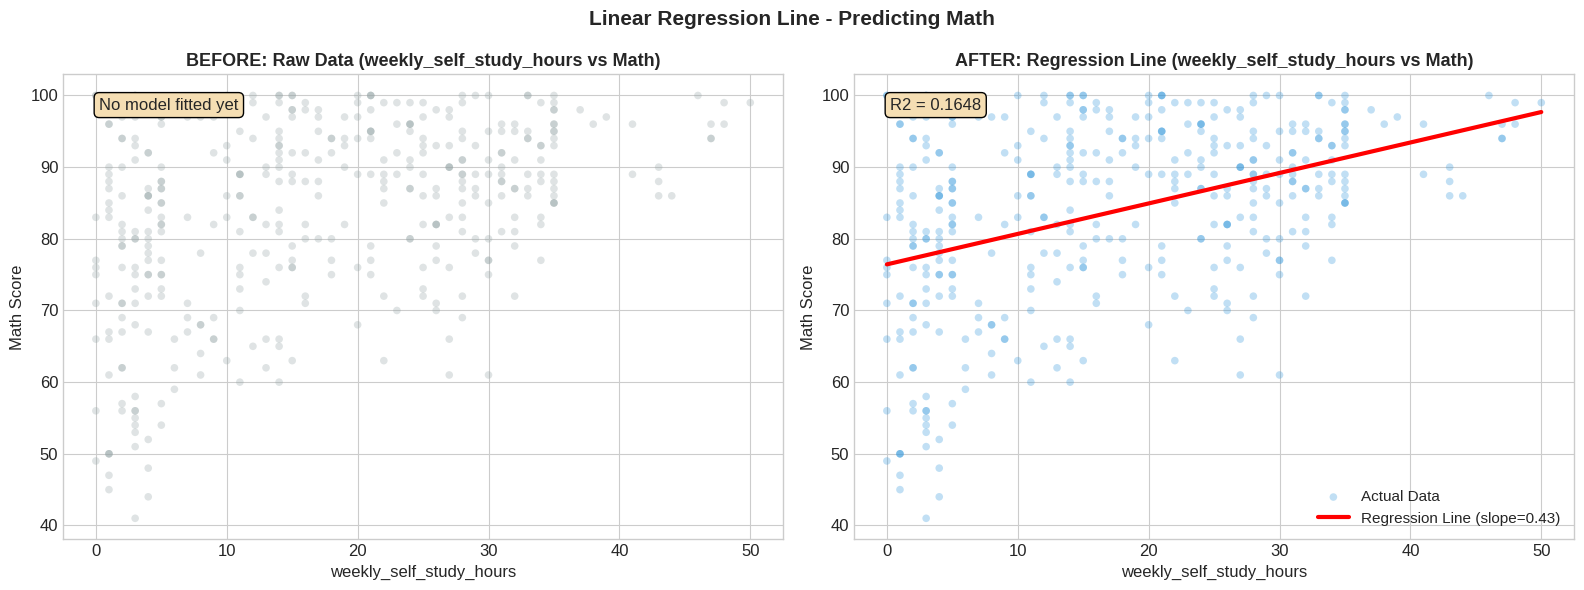

In [33]:
#Regression Line on strongest predictor
best_feature_name = target_corr.abs().sort_values(ascending=False).index[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_test[best_feature_name], y_test, alpha=0.3, color='#95a5a6', s=30, edgecolors='none')
axes[0].set_title(f'BEFORE: Raw Data ({best_feature_name} vs {TARGET_DISPLAY})', fontsize=13, fontweight='bold')
axes[0].set_xlabel(best_feature_name)
axes[0].set_ylabel(f'{TARGET_DISPLAY} Score')
axes[0].text(0.05, 0.95, 'No model fitted yet', transform=axes[0].transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

axes[1].scatter(X_test[best_feature_name], y_test, alpha=0.3, color='#3498db', s=30, edgecolors='none',
                label='Actual Data')
coeffs = np.polyfit(X_test[best_feature_name].values, y_test.values, 1)
x_line = np.linspace(X_test[best_feature_name].min(), X_test[best_feature_name].max(), 100)
y_line = np.polyval(coeffs, x_line)
axes[1].plot(x_line, y_line, 'r-', linewidth=3, label=f'Regression Line (slope={coeffs[0]:.2f})')
axes[1].set_title(f'AFTER: Regression Line ({best_feature_name} vs {TARGET_DISPLAY})', fontsize=13, fontweight='bold')
axes[1].set_xlabel(best_feature_name)
axes[1].set_ylabel(f'{TARGET_DISPLAY} Score')
axes[1].legend(fontsize=11)
simple_r2 = r2_score(y_test, np.polyval(coeffs, X_test[best_feature_name].values))
axes[1].text(0.05, 0.95, f'R2 = {simple_r2:.4f}', transform=axes[1].transAxes,
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle(f'Linear Regression Line - Predicting {TARGET_DISPLAY}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Comparison & Save Best Model

In [34]:
print("=" * 95)
print(f"{'Model':<35} {'Train MSE':>12} {'Test MSE':>12} {'Train R2':>12} {'Test R2':>12} {'Test MAE':>12}")
print("-" * 95)
for model_name, metrics in results.items():
    print(f"{model_name:<35} {metrics['Train MSE']:>12.4f} {metrics['Test MSE']:>12.4f} "
          f"{metrics['Train R2']:>12.4f} {metrics['Test R2']:>12.4f} {metrics['Test MAE']:>12.4f}")
print("=" * 95)

best_model_name = max(results, key=lambda k: results[k]['Test R2'])
print(f"\nThe BEST MODEL for predicting {TARGET_DISPLAY} score is: {best_model_name}")
print(f"  -> Test R2 = {results[best_model_name]['Test R2']:.4f}")
print(f"  -> Test MSE = {results[best_model_name]['Test MSE']:.4f}")
print(f"  -> Test MAE = {results[best_model_name]['Test MAE']:.4f}")

model_map = {
    'SGD Linear Regression': sgd_model,
    'Standard Linear Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
}
best_model_object = model_map[best_model_name]

model_filename = f'best_model_{TARGET_DISPLAY.lower()}.pkl'
scaler_filename = f'scaler_{TARGET_DISPLAY.lower()}.pkl'

joblib.dump(best_model_object, model_filename)
joblib.dump(scaler, scaler_filename)
print(f"\nSaved: {model_filename}")
print(f"Saved: {scaler_filename}")

Model                                  Train MSE     Test MSE     Train R2      Test R2     Test MAE
-----------------------------------------------------------------------------------------------
SGD Linear Regression                   140.3908     141.3551       0.2068       0.1482       9.4858
Standard Linear Regression              115.5252     121.9628       0.3473       0.2650       8.9109
Decision Tree                            72.6934     163.3027       0.5893       0.0159       9.7219
Random Forest                            58.6318     130.1938       0.6687       0.2154       9.0353

The BEST MODEL for predicting Math score is: Standard Linear Regression
  -> Test R2 = 0.2650
  -> Test MSE = 121.9628
  -> Test MAE = 8.9109

Saved: best_model_math.pkl
Saved: scaler_math.pkl


### Barchart for model comparison

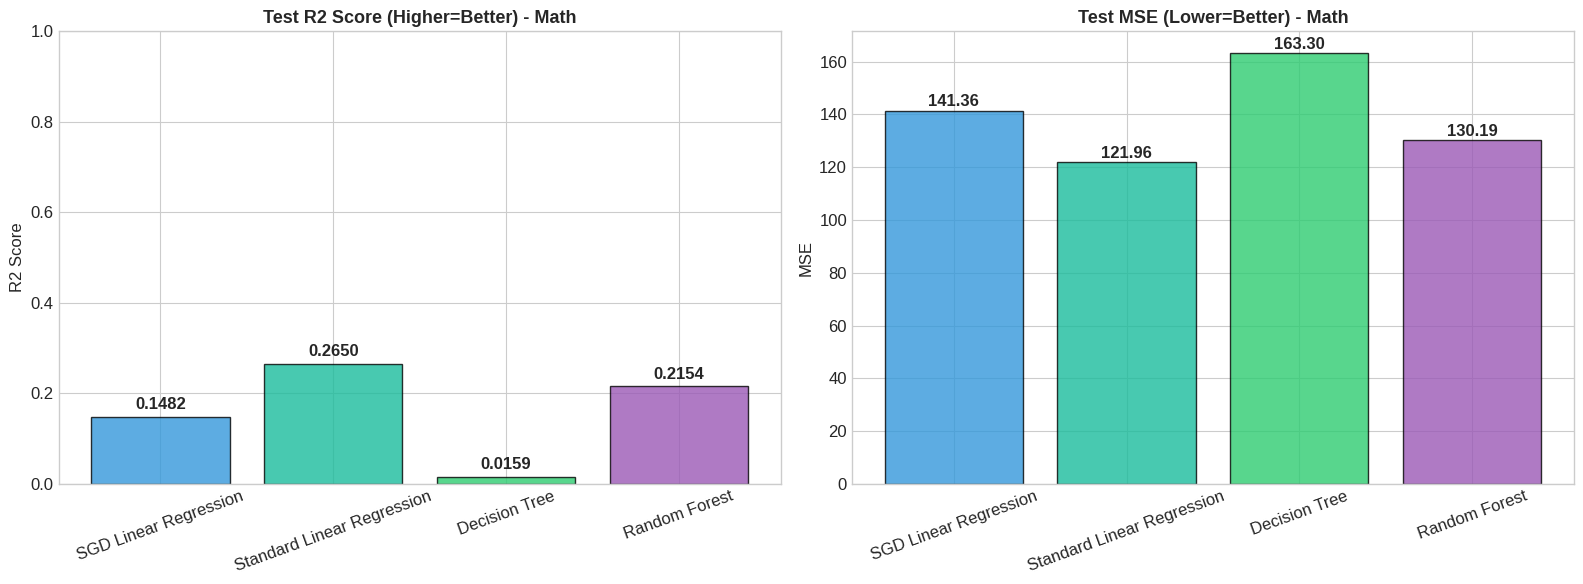

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(results.keys())
test_r2_scores = [results[m]['Test R2'] for m in model_names]
test_mse_scores = [results[m]['Test MSE'] for m in model_names]
bar_colors = ['#3498db', '#1abc9c', '#2ecc71', '#9b59b6']

bars1 = axes[0].bar(model_names, test_r2_scores, color=bar_colors, edgecolor='black', alpha=0.8)
axes[0].set_title(f'Test R2 Score (Higher=Better) - {TARGET_DISPLAY}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0, 1)
for bar, val in zip(bars1, test_r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

bars2 = axes[1].bar(model_names, test_mse_scores, color=bar_colors, edgecolor='black', alpha=0.8)
axes[1].set_title(f'Test MSE (Lower=Better) - {TARGET_DISPLAY}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MSE')
for bar, val in zip(bars2, test_mse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

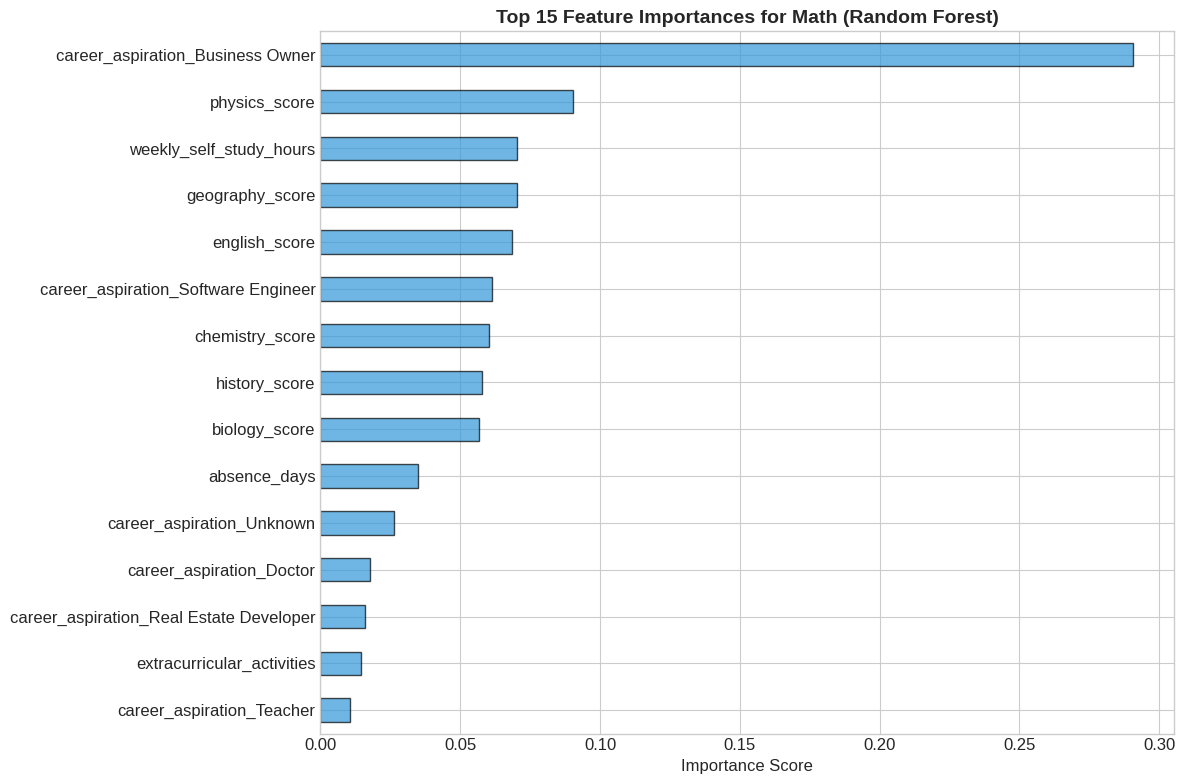

In [36]:
fig, ax = plt.subplots(figsize=(12, 8))
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importance.tail(15).plot(kind='barh', color='#3498db', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title(f'Top 15 Feature Importances for {TARGET_DISPLAY} (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Prediction on a Single Data Point from the Test Set
This demonstrates that our saved model can actually be used to predict a score for an individual student. We pick one row from the test dataset, run it through the best model, and compare the prediction to the actual score.

In [37]:
# ============================================================
# PREDICTION ON ONE DATA POINT FROM THE TEST SET
# ============================================================
# Pick one student from the test set (row index 0)
sample_index = 0
sample_row = X_test_scaled.iloc[[sample_index]]   # One row as a DataFrame
actual_score = y_test.iloc[sample_index]           # The real score for this student

# Load the saved best model (proving the .pkl file works)
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)

# Make prediction using the best model
predicted_score = loaded_model.predict(sample_row)[0]

# Show all the student's feature values
print("=" * 60)
print(f"PREDICTION ON A SINGLE STUDENT FROM TEST SET")
print("=" * 60)
print(f"\nStudent's features (scaled values):")
for col in sample_row.columns:
    print(f"  {col:40s} = {sample_row[col].values[0]:.4f}")

print(f"\n{'─' * 60}")
print(f"  ACTUAL {TARGET_DISPLAY} Score:    {actual_score}")
print(f"  PREDICTED {TARGET_DISPLAY} Score: {predicted_score:.2f}")
print(f"  Difference (error):        {abs(actual_score - predicted_score):.2f} points")
print(f"  Model used:                {best_model_name}")
print(f"{'─' * 60}")

# Also show predictions from ALL models for comparison
print(f"\nPredictions from all models for this student:")
for name, model_obj in model_map.items():
    pred = model_obj.predict(sample_row)[0]
    diff = abs(actual_score - pred)
    print(f"  {name:35s} -> Predicted: {pred:6.2f}  |  Error: {diff:.2f} points")

PREDICTION ON A SINGLE STUDENT FROM TEST SET

Student's features (scaled values):
  gender                                   = 1.0075
  part_time_job                            = -0.4344
  absence_days                             = -1.3966
  extracurricular_activities               = -0.5175
  weekly_self_study_hours                  = 0.0933
  history_score                            = 1.1746
  physics_score                            = 0.7867
  chemistry_score                          = 1.3429
  biology_score                            = 1.2182
  english_score                            = 0.7367
  geography_score                          = -1.1974
  career_aspiration_Artist                 = -0.1851
  career_aspiration_Banker                 = 3.2420
  career_aspiration_Business Owner         = -0.4232
  career_aspiration_Construction Engineer  = -0.1904
  career_aspiration_Designer               = -0.1601
  career_aspiration_Doctor                 = -0.2498
  career_aspiration_Game 